# This notebook demonstrates earthaccess new STAC capabilities and how it can operate with STAC tooling like odc-stac via the new to_stac() method.  

## Setup

Log in so earthaccess can build an authenticated registry for indirect (HTTPS) access.

In [1]:
import earthaccess

auth = earthaccess.login()
auth

Auth(authenticated=True, user='earthaccess', strategy='netrc', system=urs.earthdata.nasa.gov)

In [2]:
sst_granules = earthaccess.search_data(
    short_name="HLSL30",
    temporal=("2025-01-01", "2025-01-20"),
    bounding_box=(40.19, 6.24, 42.18, 7.24),
    count=10,
)

In [6]:
sst_granules

#,Name,Date,Size,Cloud,Link
1,HLS.L30.T37NGJ.2025001T073419.v2.0,2025-01-01,113.49 MB,☁️,📥
2,HLS.L30.T37NFJ.2025001T073419.v2.0,2025-01-01,180.58 MB,☁️,📥
3,HLS.L30.T37NGH.2025001T073443.v2.0,2025-01-01,79.08 MB,☁️,📥
4,HLS.L30.T37NFH.2025001T073443.v2.0,2025-01-01,177.11 MB,☁️,📥
5,HLS.L30.T37NFG.2025001T073507.v2.0,2025-01-01,175.64 MB,☁️,📥
6,HLS.L30.T37NGG.2025001T073507.v2.0,2025-01-01,46.29 MB,☁️,📥
7,HLS.L30.T37NHJ.2025002T072805.v2.0,2025-01-02,179.03 MB,☁️,📥
8,HLS.L30.T37NGJ.2025002T072805.v2.0,2025-01-02,101.58 MB,☁️,📥
9,HLS.L30.T37NGH.2025002T072829.v2.0,2025-01-02,134.9 MB,☁️,📥
10,HLS.L30.T37NHH.2025002T072829.v2.0,2025-01-02,178.46 MB,☁️,📥


In [7]:
sst_granules.plot()

In [8]:
items = sst_granules.to_stac()

In [10]:
%%time 

import rasterio
from odc.stac import stac_load

with rasterio.Env(
    GDAL_HTTP_HEADERS=f"Authorization: Bearer {auth.token['access_token']}",
    CPL_VSIL_CURL_USE_HEAD="NO",
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
    VSI_CACHE=True,
):
    mosaic = stac_load(
        items,
        bands=["B04", "B05"],
        crs="EPSG:32637",
        resolution=30,
    )

mosaic

CPU times: user 5.6 s, sys: 1.88 s, total: 7.48 s
Wall time: 1min 12s


<xarray.Dataset> Size: 4GB
Dimensions:      (y: 10327, x: 10327, time: 5)
Coordinates:
  * y            (y) float64 83kB 9e+05 9e+05 8.999e+05 ... 5.902e+05 5.902e+05
  * x            (x) float64 83kB 6e+05 6e+05 6.001e+05 ... 9.098e+05 9.098e+05
  * time         (time) datetime64[us] 40B 2025-01-01T07:34:19.205000 ... 202...
    spatial_ref  int32 4B 32637
Data variables:
    B04          (time, y, x) float32 2GB 1.5e+03 1.642e+03 ... nan nan
    B05          (time, y, x) float32 2GB 3.274e+03 3.494e+03 ... nan nan

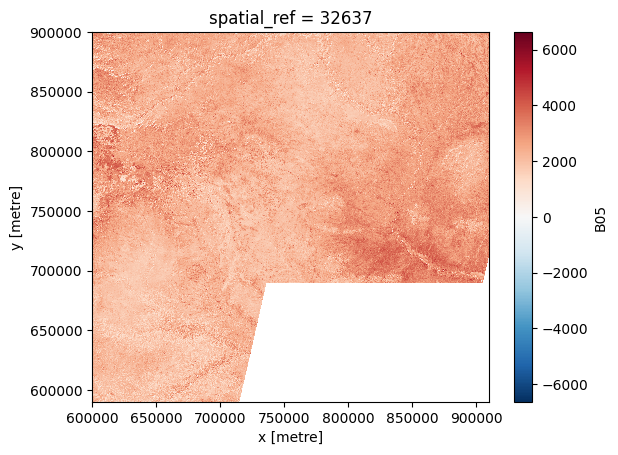

In [11]:
mosaic.B05.mean(dim="time").plot.imshow()